In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# -----------------------------------------------
# 1. Load Cleaned Dataset
# -----------------------------------------------

df = pd.read_csv('../data/cleaned/crypto_dataset_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"Dataset loaded with shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")


df.isnull().sum().sum()

# print("\nDescriptive statistics for all cryptocurrencies:")
# print(df.describe())

Dataset loaded with shape: (365, 31)
Date range: 2024-07-01 to 2025-06-30


0

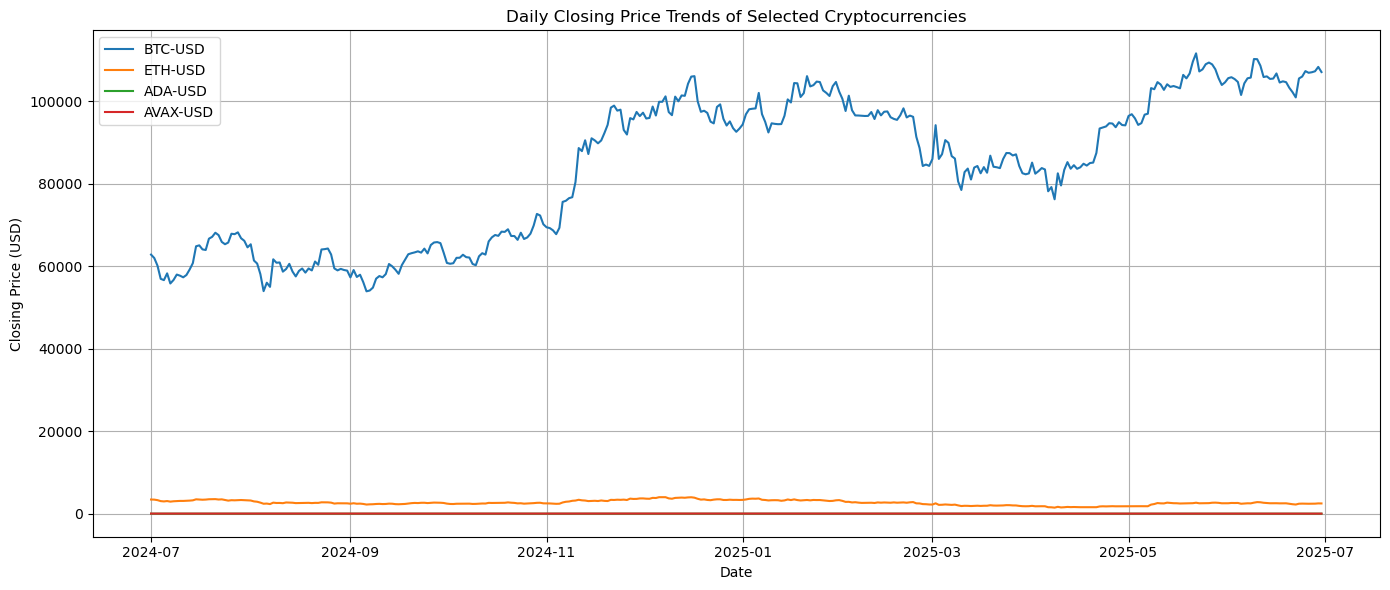

In [3]:
# -----------------------------------------------
# 2. Time Series Price Trends for Representative Coins
# -----------------------------------------------
plt.figure(figsize=(14, 6))
selected_coins = ['BTC-USD', 'ETH-USD', 'ADA-USD', 'AVAX-USD']  # Representative coins for visualization
for coin in selected_coins:
    if coin in df.columns:
        plt.plot(df['Date'], df[coin], label=coin)
plt.title('Daily Closing Price Trends of Selected Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

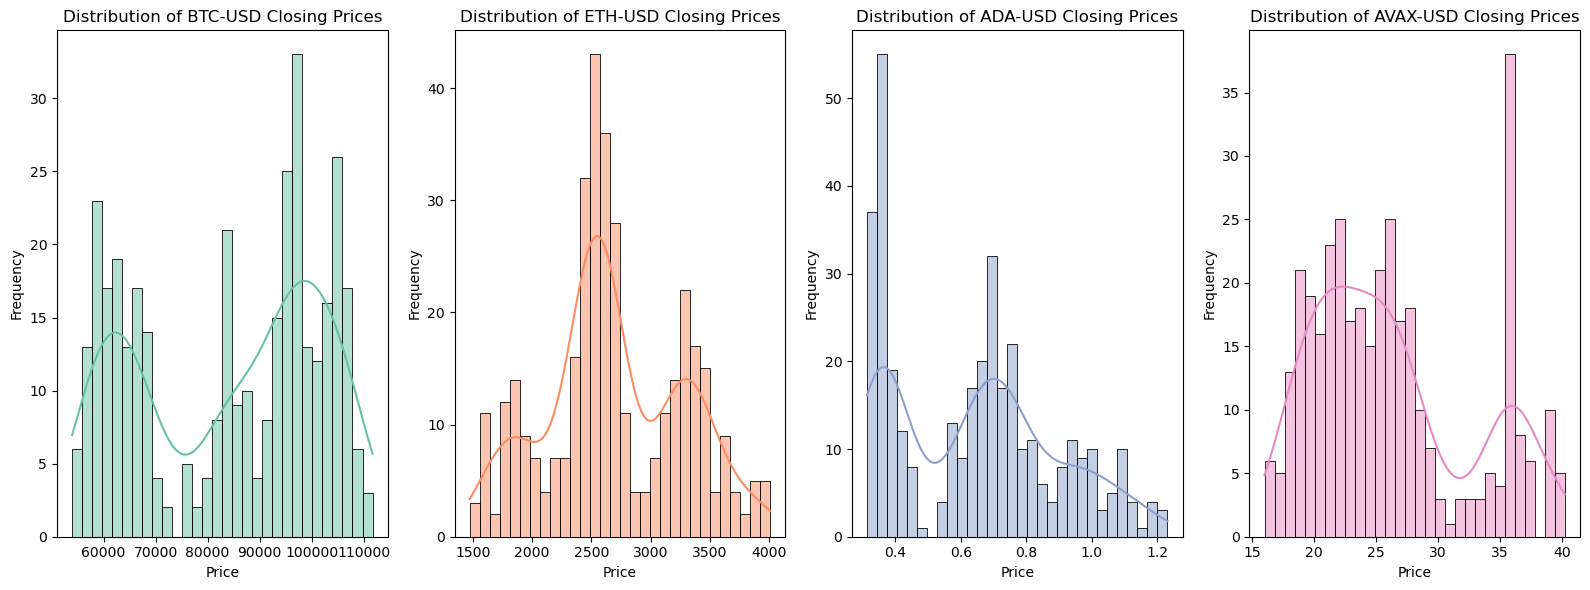

In [4]:
# -----------------------------------------------
# 3. Distribution Analysis of Selected Coins
# -----------------------------------------------
plt.figure(figsize=(16, 6))
for i, coin in enumerate(selected_coins):
    if coin in df.columns:
        plt.subplot(1, len(selected_coins), i+1)
        sns.histplot(df[coin], bins=30, kde=True, color=sns.color_palette('Set2')[i])
        plt.title(f'Distribution of {coin} Closing Prices')
        plt.xlabel('Price')
        plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

/var/folders/rs/5fvy4hss7cvgk5msj3vhn6t80000gn/T/ipykernel_63736/1512171640.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cryptocurrency', y='Price', data=melted_df, palette='Set2')


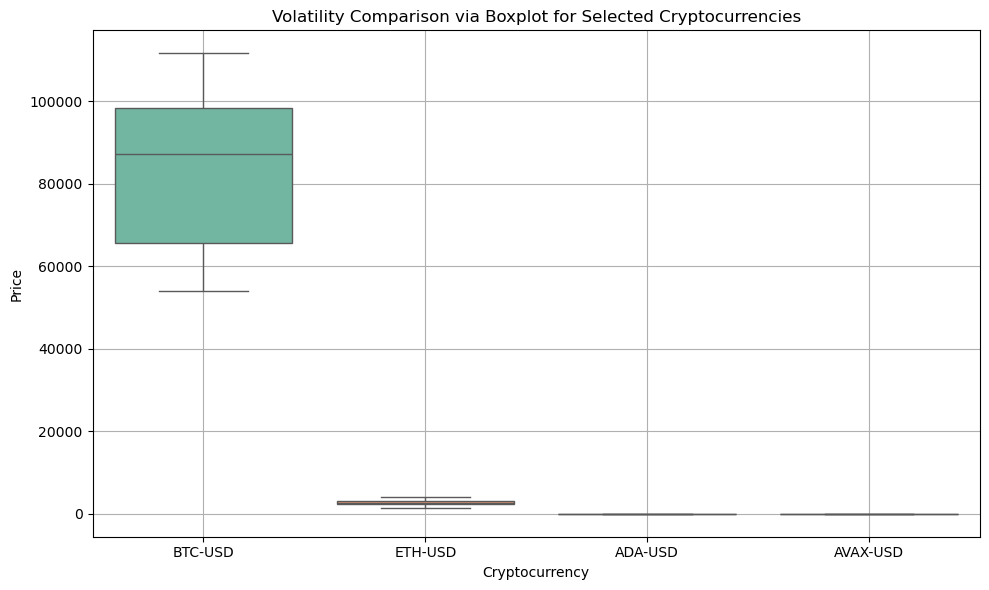

In [5]:
# Boxplot comparison of selected coins
melted_df = df[selected_coins].melt(var_name='Cryptocurrency', value_name='Price')
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cryptocurrency', y='Price', data=melted_df, palette='Set2')
plt.title('Volatility Comparison via Boxplot for Selected Cryptocurrencies')
plt.ylabel('Price')
plt.grid(True)
plt.tight_layout()
plt.show()

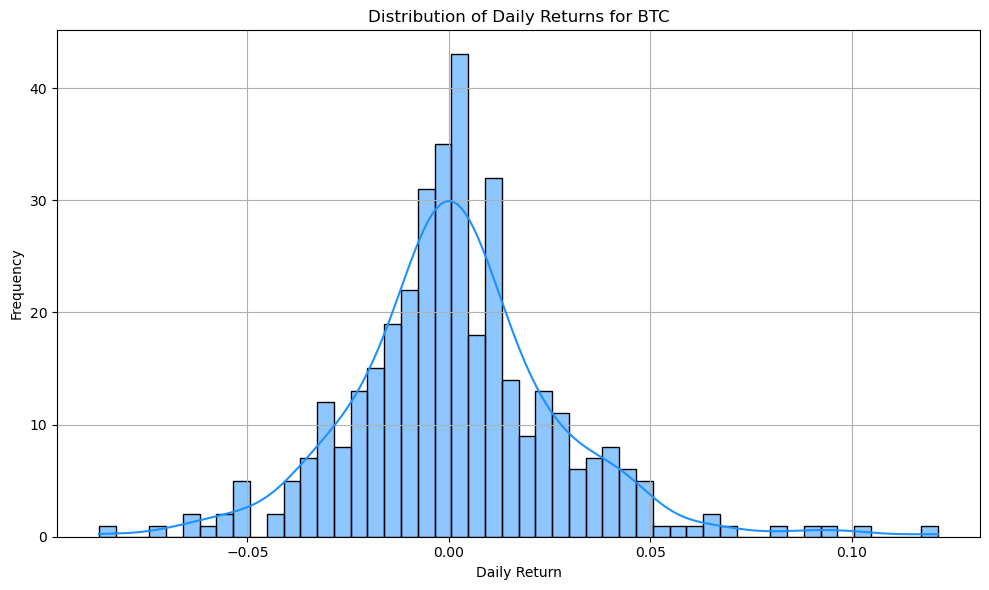

In [6]:
# -----------------------------------------------
# 4. Returns Distribution and Analysis for BTC
# -----------------------------------------------
df['BTC_Returns'] = df['BTC-USD'].pct_change()
btc_returns = df['BTC_Returns'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(btc_returns, bins=50, kde=True, color='dodgerblue')
plt.title('Distribution of Daily Returns for BTC')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

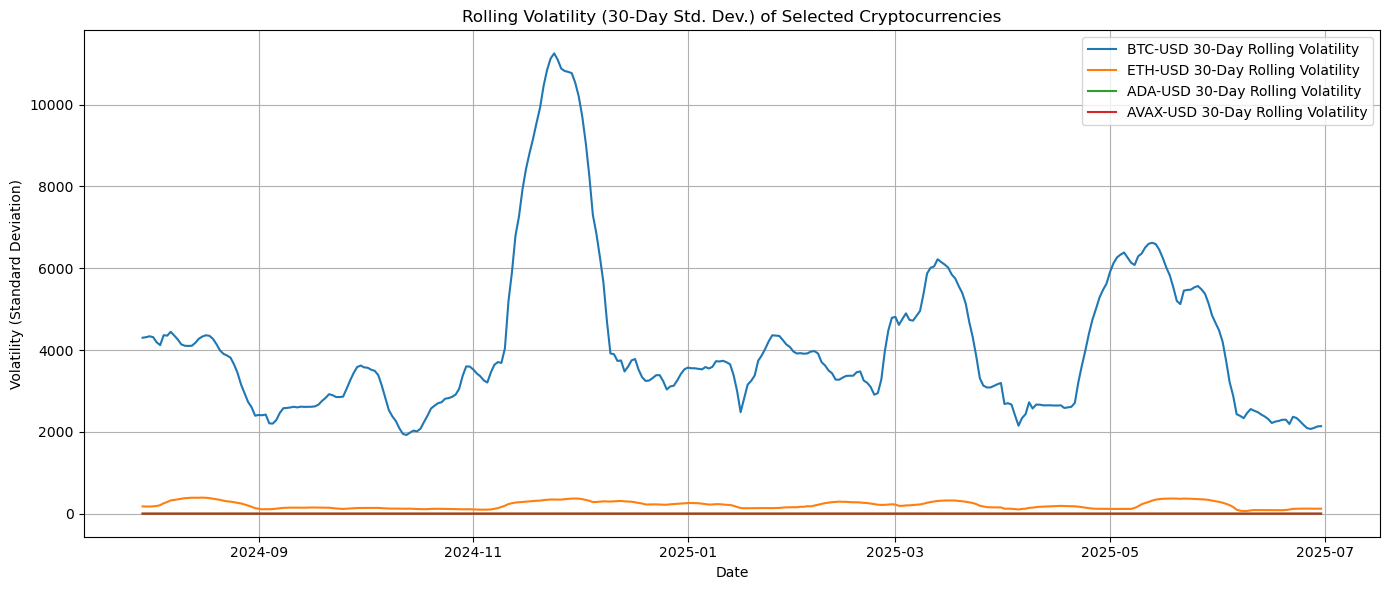

In [7]:
# -----------------------------------------------
# 5. Rolling Volatility (Standard Deviation) for Selected Coins
# -----------------------------------------------
plt.figure(figsize=(14, 6))
rolling_window = 30
for coin in selected_coins:
    if coin in df.columns:
        rolling_vol = df[coin].rolling(window=rolling_window).std()
        plt.plot(df['Date'], rolling_vol, label=f'{coin} {rolling_window}-Day Rolling Volatility')
plt.title('Rolling Volatility (30-Day Std. Dev.) of Selected Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

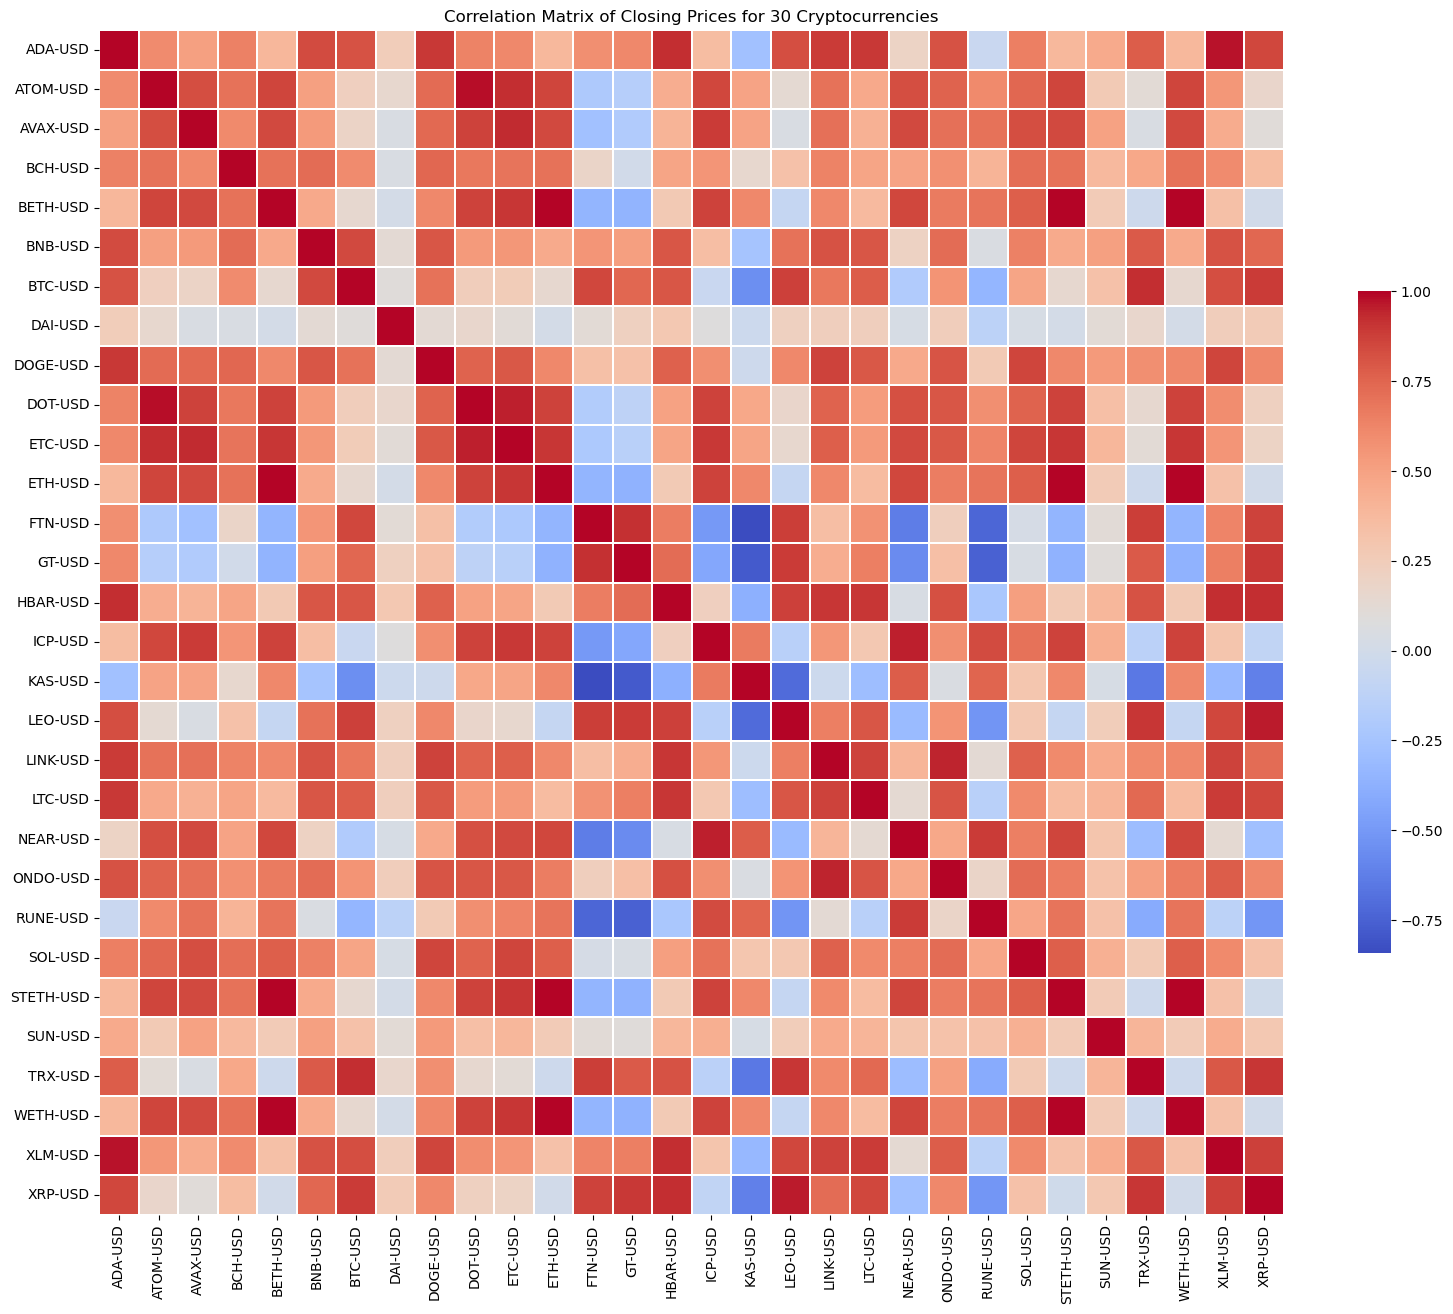

In [8]:
# -----------------------------------------------
# 6. Correlation Matrix and Heatmap for All 30 Coins
# -----------------------------------------------
corr_matrix = df.drop(['Date','BTC_Returns'], axis=1, errors='ignore').corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False,
    square=True,
    cbar_kws={'shrink': 0.5},
    linewidths=0.3
)
plt.title('Correlation Matrix of Closing Prices for 30 Cryptocurrencies')
plt.tight_layout()
plt.show()

## Transpose Data for PCA and Clustering

In [10]:
# # Remove 'Month' column if present
# df = df.drop('Month', axis=1, errors='ignore')

# # Ensure 'Date' is datetime
# df['Date'] = pd.to_datetime(df['Date'])

# # Set 'Date' as index
# df = df.set_index('Date')

# # Transpose: cryptocurrencies as rows, dates as columns
# df_transposed = df.T

# # Reset index to bring 'Symbol' as a column
# df_transposed.reset_index(inplace=True)
# df_transposed = df_transposed.rename(columns={'index': 'Symbol'})

# # Format date columns to string 'YYYY-MM-DD'
# df_transposed.columns = [
#     col.strftime('%Y-%m-%d') if isinstance(col, pd.Timestamp) else col for col in df_transposed.columns
# ]

# # Check for missing values after transpose
# print("Missing values per column after transpose:")
# print(df_transposed.isnull().sum())

# # --- FILL ONLY NUMERIC COLUMNS ---
# numeric_cols = df_transposed.columns.drop('Symbol')

# # 1. Forward then backward fill (along dates)
# df_transposed[numeric_cols] = df_transposed[numeric_cols].ffill(axis=1).bfill(axis=1).infer_objects(copy=False)

# # 2. Fill any remaining missing values with row mean (per coin)
# for idx, row in df_transposed[numeric_cols].iterrows():
#     if row.isnull().any():
#         mean_value = row.mean(skipna=True)
#         df_transposed.loc[idx, numeric_cols] = row.fillna(mean_value)

# # Confirm missing values resolved
# print("Missing values after filling:")
# print(df_transposed.isnull().sum())

# # --- SAVE ---
# df_transposed.to_csv('../data/processed/crypto_dataset_transposed.csv', index=False)
# print("Transposed dataset saved as '../data/processed/crypto_dataset_transposed.csv'")


In [11]:
# Load the cleaned dataset
df = pd.read_csv('../data/cleaned/crypto_dataset_cleaned.csv')

# Ensure 'Date' column is datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as the index
df = df.set_index('Date')

# Transpose the DataFrame so cryptocurrencies are rows and dates are columns
df_transposed = df.T

# Reset index to bring cryptocurrency symbols as a column named 'Symbol'
df_transposed.reset_index(inplace=True)
df_transposed = df_transposed.rename(columns={'index': 'Symbol'})

# Format date columns as string 'YYYY-MM-DD' for clean saving
df_transposed.columns = [
    col.strftime('%Y-%m-%d') if isinstance(col, pd.Timestamp) else col for col in df_transposed.columns
]

# Check for any missing values after transpose (should be zero)
print("Missing values per column after transpose:")
print(df_transposed.isnull().sum())

# Save the transposed dataset for PCA and clustering
df_transposed.to_csv('../data/processed/crypto_dataset_transposed.csv', index=False)
print("Transposed dataset saved as '../data/processed/crypto_dataset_transposed.csv'")


Missing values per column after transpose:
Symbol        0
2024-07-01    0
2024-07-02    0
2024-07-03    0
2024-07-04    0
             ..
2025-06-26    0
2025-06-27    0
2025-06-28    0
2025-06-29    0
2025-06-30    0
Length: 366, dtype: int64
Transposed dataset saved as '../data/processed/crypto_dataset_transposed.csv'
